# Logistic Regression

### Importing Libraries

In [3]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Importing the data

In [4]:
data = pd.read_csv("data_cleaned.csv")
data.head()

,Survived,Age,Fare,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,SibSp_0,SibSp_1,...,Parch_0,Parch_1,Parch_2,Parch_3,Parch_4,Parch_5,Parch_6,Embarked_C,Embarked_Q,Embarked_S
0,0,22.0,7.2500,0,0,1,0,1,0,1,...,1,0,0,0,0,0,0,0,0,1
1,1,38.0,71.2833,1,0,0,1,0,0,1,...,1,0,0,0,0,0,0,1,0,0
2,1,26.0,7.9250,0,0,1,1,0,1,0,...,1,0,0,0,0,0,0,0,0,1
3,1,35.0,53.1000,1,0,0,1,0,0,1,...,1,0,0,0,0,0,0,0,0,1
4,0,35.0,8.0500,0,0,1,0,1,1,0,...,1,0,0,0,0,0,0,0,0,1


### Segregating variables: Independent and Dependent Variables

In [5]:
# seperating independent and dependent variables
x = data.drop(["Survived"], axis=1)
y = data["Survived"]
x.shape, y.shape

((891, 24), (891,))

### Splitting the data into train set and the test set

In [6]:
# Importing the train test split function
from sklearn.model_selection import train_test_split

train_x, test_x, train_y, test_y = train_test_split(x, y, random_state=56)

### Normalising using *min_max_scaler*

In [7]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

In [8]:
cols = train_x.columns
cols

Index(['Age', 'Fare', 'Pclass_1', 'Pclass_2', 'Pclass_3', 'Sex_female',
       'Sex_male', 'SibSp_0', 'SibSp_1', 'SibSp_2', 'SibSp_3', 'SibSp_4',
       'SibSp_5', 'SibSp_8', 'Parch_0', 'Parch_1', 'Parch_2', 'Parch_3',
       'Parch_4', 'Parch_5', 'Parch_6', 'Embarked_C', 'Embarked_Q',
       'Embarked_S'],
      dtype='object')

In [9]:
train_x_scaled = scaler.fit_transform(train_x)
train_x_scaled = pd.DataFrame(train_x_scaled, columns=cols)
train_x_scaled.head()

,Age,Fare,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,SibSp_0,SibSp_1,SibSp_2,...,Parch_0,Parch_1,Parch_2,Parch_3,Parch_4,Parch_5,Parch_6,Embarked_C,Embarked_Q,Embarked_S
0,0.371701,0.024350,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.334004,0.016908,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.396833,0.015127,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.786378,0.152164,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.334004,0.412821,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [10]:
test_x_scaled = scaler.transform(test_x)
test_x_scaled = pd.DataFrame(test_x_scaled, columns=cols)
test_x_scaled.head()

,Age,Fare,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,SibSp_0,SibSp_1,SibSp_2,...,Parch_0,Parch_1,Parch_2,Parch_3,Parch_4,Parch_5,Parch_6,Embarked_C,Embarked_Q,Embarked_S
0,0.396833,0.143462,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.359135,0.129995,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.367921,0.014110,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.346569,0.025374,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.371701,0.054164,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


### Implementing Logistic Regression

In [11]:
# importing Logistic Regression and metric F1-score
from sklearn.linear_model import LogisticRegression as LogReg
from sklearn.metrics import f1_score

In [12]:
# Creating instance of Logistic Regresssion
logreg = LogReg()

# Fitting the model
logreg.fit(train_x, train_y)

/Users/amitpandey/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

### Making predictions using *predict* function

In [13]:
# Predicting over the Train
train_predict = logreg.predict(train_x)
train_predict

array([0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1,

In [14]:
# Calculating f1-score
k = f1_score(train_predict, train_y)
print("Training f1_score", k)

Training f1_score 0.7514910536779325


In [15]:
# Predicting over the Test Set and f1-score
test_predict = logreg.predict(test_x)
k = f1_score(test_predict, test_y)
print("Test f1_score    ", k)

Test f1_score     0.736842105263158


### Making predictions using *predict_proba* function

In [53]:
# Predicting over the Train
train_predict = logreg.predict_proba(train_x)
train_predict

array([[0.49167915, 0.50832085],
       [0.90628996, 0.09371004],
       [0.86766355, 0.13233645],
       ...,
       [0.25374215, 0.74625785],
       [0.43257968, 0.56742032],
       [0.0765409 , 0.9234591 ]])

In [54]:
train_preds = train_predict[:, 1]
train_preds

array([0.50832085, 0.09371004, 0.13233645, 0.88460305, 0.5372753 ,
       0.09371004, 0.8126695 , 0.74625785, 0.62666633, 0.05392632,
       0.09371004, 0.09371004, 0.09371004, 0.09371004, 0.67367941,
       0.09371004, 0.38140417, 0.09371004, 0.09371004, 0.33477321,
       0.09371004, 0.2272881 , 0.2272881 , 0.53226614, 0.09371004,
       0.50832085, 0.09371004, 0.51335199, 0.6039579 , 0.09371004,
       0.85197878, 0.09371004, 0.38140417, 0.13233645, 0.02567549,
       0.775869  , 0.2272881 , 0.15031395, 0.09371004, 0.2272881 ,
       0.87155807, 0.38140417, 0.38140417, 0.63883231, 0.56742032,
       0.89404283, 0.2272881 , 0.50832085, 0.15031395, 0.87155807,
       0.09371004, 0.51335199, 0.2272881 , 0.6039579 , 0.38140417,
       0.5372753 , 0.74625785, 0.2272881 , 0.09371004, 0.5372753 ,
       0.50832085, 0.2272881 , 0.15031395, 0.38140417, 0.2272881 ,
       0.92915454, 0.09371004, 0.09371004, 0.87740894, 0.63988337,
       0.91339897, 0.66066461, 0.87740894, 0.38140417, 0.76399

In [55]:
for i in range(0, len(train_preds)):
    if train_preds[i] > 0.60:
        train_preds[i] = 1
    else:
        train_preds[i] = 0

In [56]:
# Calculating f1-score
k = f1_score(train_preds, train_y)
print("Training f1_score", k)

Training f1_score 0.7108167770419426


# Confusion matrix

In [20]:
from sklearn.metrics import confusion_matrix

cf = confusion_matrix(test_y, test_predict)
print(cf)

[[127  17]
 [ 23  56]]


In [21]:
from sklearn.metrics import classification_report as rep

print(rep(test_y, test_predict))

              precision    recall  f1-score   support

           0       0.85      0.88      0.86       144
           1       0.77      0.71      0.74        79

    accuracy                           0.82       223
   macro avg       0.81      0.80      0.80       223
weighted avg       0.82      0.82      0.82       223



# Parameters of Logistic Regression

In [22]:
# printing the coefficients
logreg.coef_

array([[-0.03572368,  0.0028677 ,  1.02031706,  0.15157231, -1.08329798,
         1.19148431, -1.10289293,  0.84838738,  1.06214958,  0.35034882,
        -0.67513695, -0.7859117 , -0.28525991, -0.42598583,  0.12613429,
         0.5999097 , -0.18744087,  0.21092794, -0.35220805, -0.14135754,
        -0.16737407,  0.14499082,  0.23424141, -0.29064084]])

### Plotting the coefficients

Text(0.5, 1.0, 'Coefficient plot')

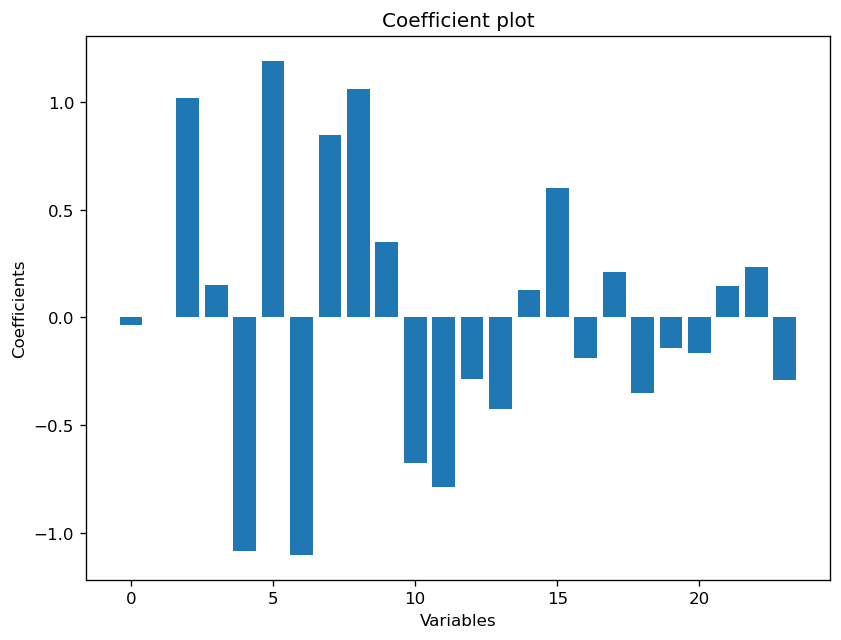

In [23]:
plt.figure(figsize=(8, 6), dpi=120, facecolor="w", edgecolor="b")
x = range(len(train_x.columns))
c = logreg.coef_.reshape(-1)
plt.bar(x, c)
plt.xlabel("Variables")
plt.ylabel("Coefficients")
plt.title("Coefficient plot")

In [28]:
Coefficients = pd.DataFrame({"Variable": train_x.columns, "coefficient": abs(c)})
Coefficients.head(20)

,Variable,coefficient
0,Age,0.035724
1,Fare,0.002868
2,Pclass_1,1.020317
3,Pclass_2,0.151572
4,Pclass_3,1.083298
5,Sex_female,1.191484
6,Sex_male,1.102893
7,SibSp_0,0.848387
8,SibSp_1,1.062150
9,SibSp_2,0.350349


In [37]:
# selecting variables with high coefficient
sig_var = Coefficients[Coefficients.coefficient > 0.1]

In [38]:
subset = data[sig_var["Variable"].values]
subset.head()

,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,SibSp_0,SibSp_1,SibSp_2,SibSp_3,SibSp_4,...,Parch_0,Parch_1,Parch_2,Parch_3,Parch_4,Parch_5,Parch_6,Embarked_C,Embarked_Q,Embarked_S
0,0,0,1,0,1,0,1,0,0,0,...,1,0,0,0,0,0,0,0,0,1
1,1,0,0,1,0,0,1,0,0,0,...,1,0,0,0,0,0,0,1,0,0
2,0,0,1,1,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
3,1,0,0,1,0,0,1,0,0,0,...,1,0,0,0,0,0,0,0,0,1
4,0,0,1,0,1,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1


In [40]:
# Using train test split function
train_x, test_x, train_y, test_y = train_test_split(subset, y, random_state=56)

### Implementing Logistic Regression

In [41]:
# Creating instance of Logistic Regresssion
logreg = LogReg()

# Fitting the model
logreg.fit(train_x, train_y)

LogisticRegression()

### Making predictions using *predict* function

In [42]:
# Predicting over the Train
train_predict = logreg.predict(train_x)
k = f1_score(train_predict, train_y)
print("Training f1_score", k)

Training f1_score 0.7090558766859345


Text(0.5, 1.0, 'Coefficient plot')

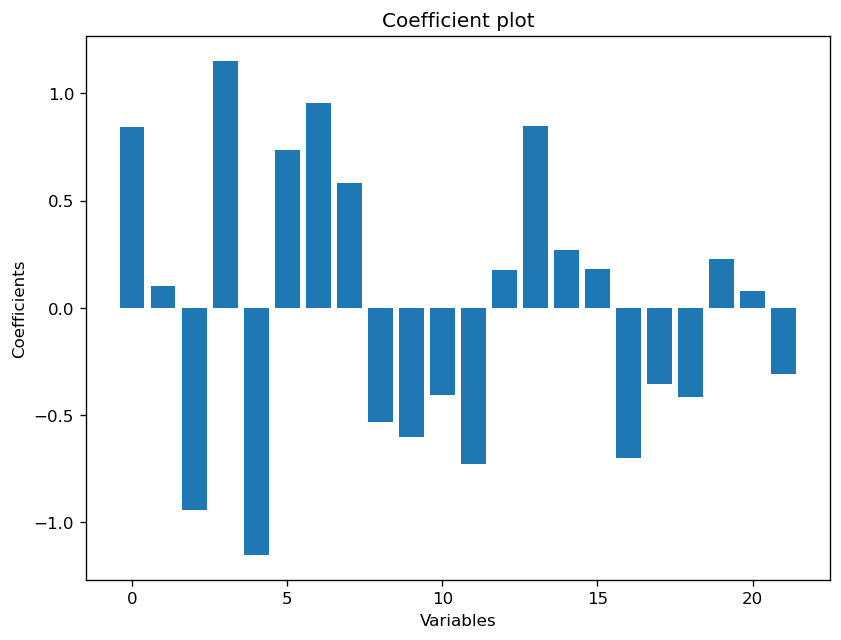

In [43]:
plt.figure(figsize=(8, 6), dpi=120, facecolor="w", edgecolor="b")
x = range(len(train_x.columns))
c = logreg.coef_.reshape(-1)
plt.bar(x, c)
plt.xlabel("Variables")
plt.ylabel("Coefficients")
plt.title("Coefficient plot")